In [4]:
import pandas as pd

df = pd.read_csv('/content/retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
# Initial Inspection

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows: 0


In [6]:
# Descriptive Statistics

numeric_columns = df.select_dtypes(include='number').columns

print("Mean:")
print(df[numeric_columns].mean())

print("\nMedian:")
print(df[numeric_columns].median())

print("\nMode:")
print(df[numeric_columns].mode().iloc[0])

print("\nStandard Deviation:")
print(df[numeric_columns].std())

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [7]:
df['Date']=pd.to_datetime(df['Date'])
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


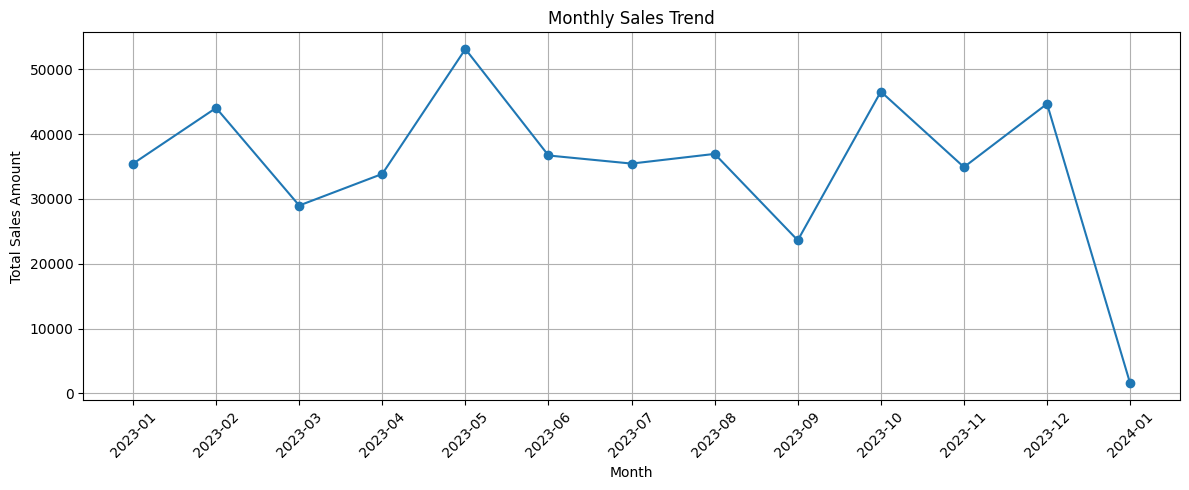

In [8]:
import matplotlib.pyplot as plt

# Monthly sales analysis
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation – Monthly Sales Trend

The monthly sales show noticeable fluctuations throughout the period. Sales reach their highest level around May, while the lowest sales are observed in the final month. This indicates that sales performance varies considerably across months and may be influenced by seasonal or customer-demand patterns.

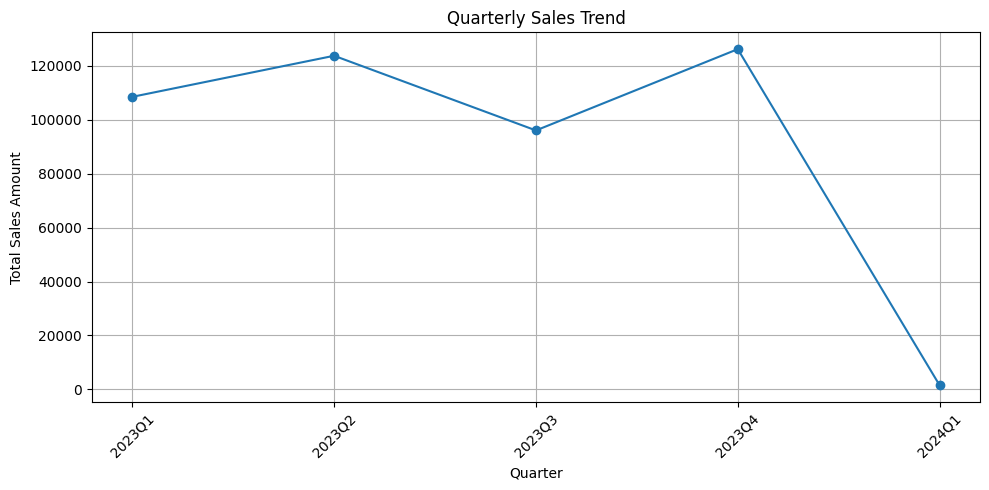

In [9]:
# Quarterly Sales Analysis

quarterly_sales = df.groupby(
    df['Date'].dt.to_period('Q')
)['Total Amount'].sum()

quarterly_sales.index = quarterly_sales.index.astype(str)

plt.figure(figsize=(10, 5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation – Quarterly Sales Trend

Quarterly sales fluctuate across the period. Sales reach their highest level in 2023 Q2, followed by a strong performance in 2023 Q4. Sales decline in 2023 Q3. The value for 2024 Q1 is much lower than the previous quarters, which may reflect that the dataset contains only a partial period for that quarter.

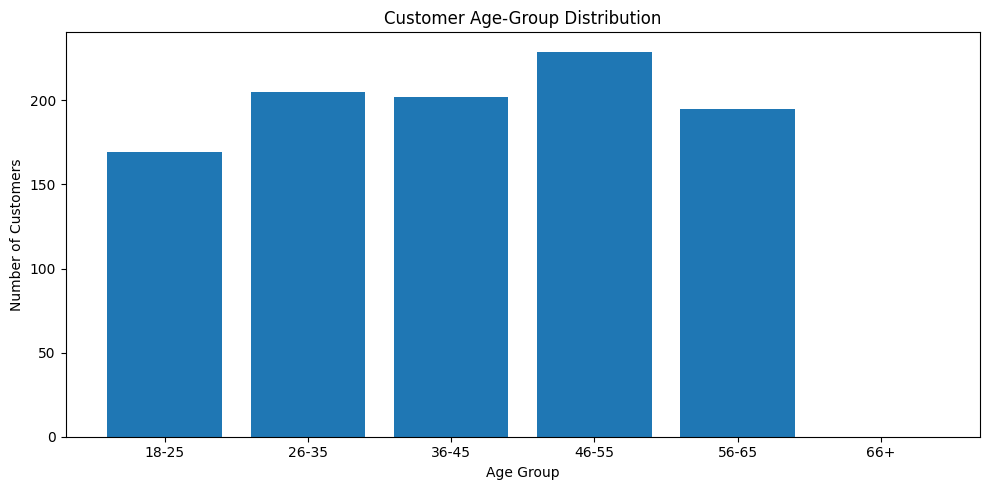

In [10]:
# Customer Age Group Distribution

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=True
)

age_group_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(age_group_counts.index.astype(str), age_group_counts.values)
plt.title('Customer Age-Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Observation – Customer Age-Group Distribution

The 46–55 age group has the highest number of customers, followed by the 26–35 and 36–45 age groups. The 18–25 and 56–65 groups have comparatively fewer customers, while no customers are recorded in the 66+ age group. This indicates that the dataset is mainly represented by customers between 26 and 55 years of age.

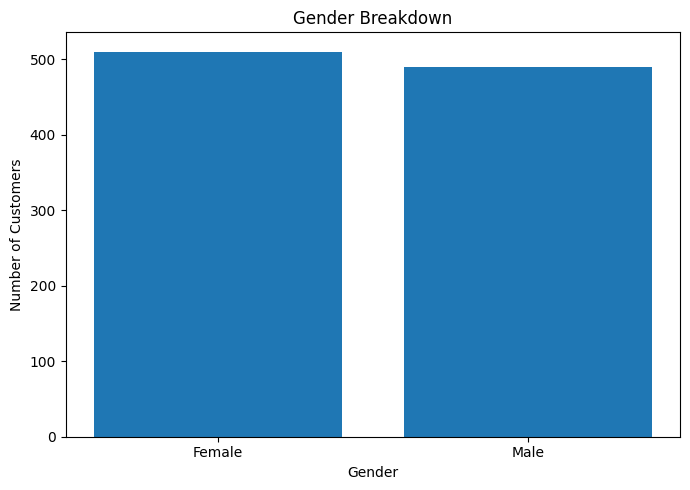

In [11]:
# Gender Breakdown

gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts.values)
plt.title('Gender Breakdown')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Observation – Gender Breakdown

The gender distribution is relatively balanced, with female and male customers having similar representation in the dataset. This indicates that the customer base is not strongly dominated by either gender.

In [15]:
import pandas as pd

df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

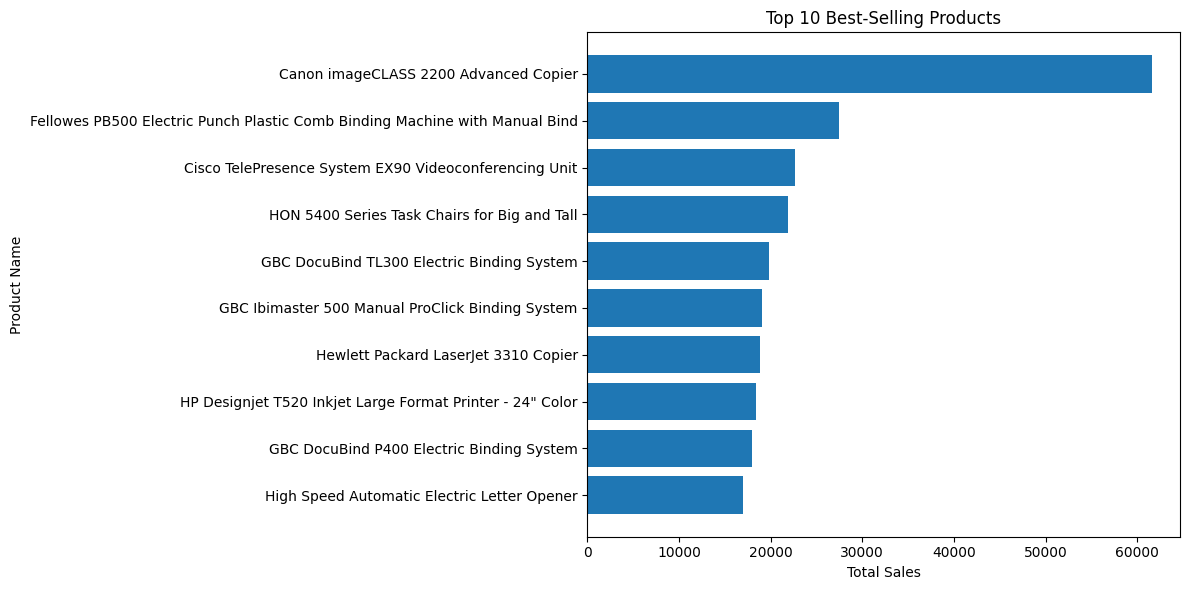

In [16]:
# Top 10 Best-Selling Products

top_10_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
plt.barh(top_10_products.index[::-1], top_10_products.values[::-1])

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

### Observation – Top 10 Best-Selling Products

Canon imageCLASS 2200 Advanced Copier has the highest total sales among the top 10 products. The remaining products show comparatively lower sales, with the Fellowes PBS500 Electric Punch Plastic Comb Binding Machine ranking second. Overall, a small number of products contribute substantially to the total sales.

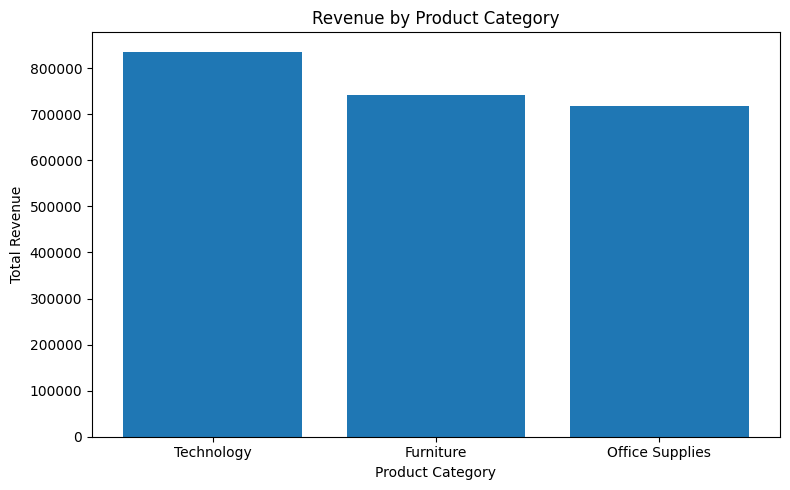

In [17]:
# Revenue by Product Category

category_revenue = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(category_revenue.index, category_revenue.values)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

### Observation – Revenue by Product Category

Technology generates the highest revenue among the three product categories. Furniture contributes the second-highest revenue, while Office Supplies has the lowest revenue. This indicates that Technology is the strongest revenue-generating category in the dataset.

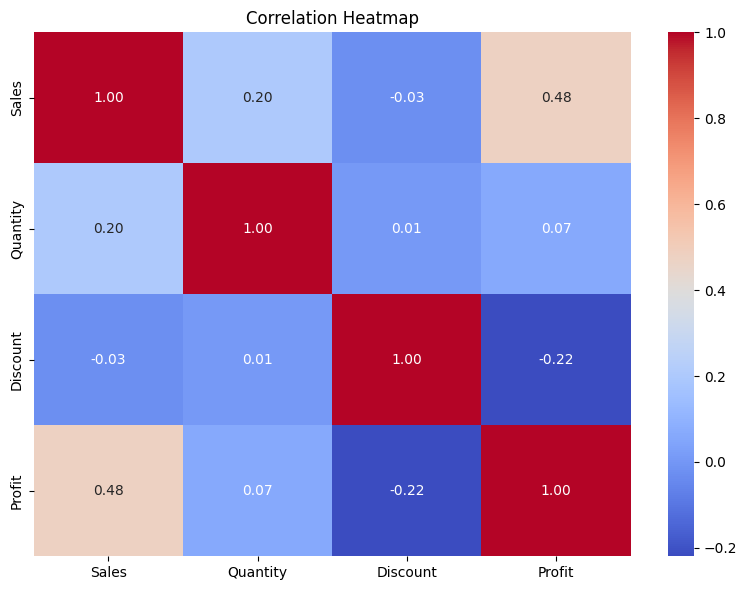

In [19]:
# Correlation Heatmap

corr_data = df[['Sales', 'Quantity', 'Discount', 'Profit']]

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observation – Correlation Heatmap

- Sales and Profit have a positive correlation of 0.48.
- Sales and Quantity have a weak positive correlation of 0.20.
- Discount and Profit have a negative correlation of -0.22.
- Quantity and Profit have a very weak positive correlation of 0.07.
- Sales has the strongest positive relationship with Profit.

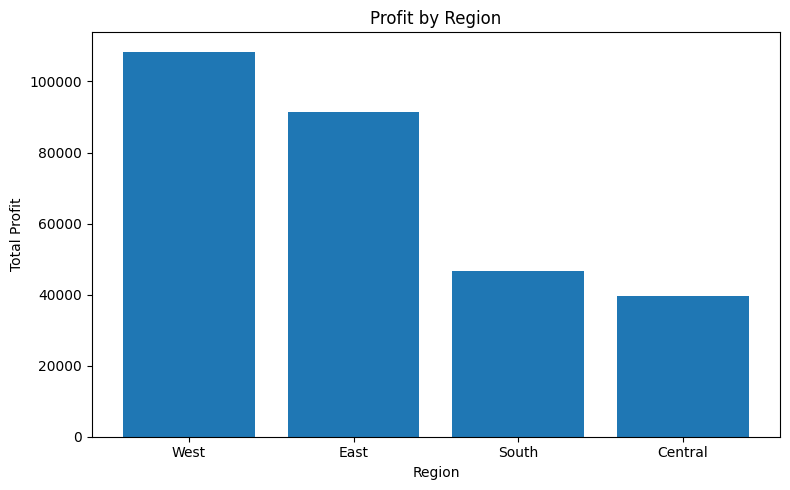

In [20]:
# Additional Visualization – Profit by Region

region_profit = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(region_profit.index, region_profit.values)

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

### Observation – Profit by Region

- West region has the highest total profit.
- East region has the second-highest total profit.
- South region has lower profit compared to West and East.
- Central region has the lowest total profit.
- West region is the most profitable region.

## Conclusion

### Key Business Recommendations

1. **Focus on high-performing products:** Prioritize inventory, promotions, and marketing for the top-selling products to maintain strong sales performance.

2. **Strengthen the Technology category:** Technology generates the highest revenue, so the business should continue investing in this category and identify opportunities to expand its product range.

3. **Improve regional performance:** The Central region has the lowest profit compared with the other regions. The business should investigate pricing, discounts, product mix, and customer demand in this region to improve profitability.

4. **Control excessive discounting:** The negative relationship between Discount and Profit suggests that higher discounts may reduce profitability. Discounts should therefore be targeted carefully and used where they are most likely to increase profitable sales.